### RideWise --- Exploratory Data Analysis (EDA)

#### STEP 1 - Setup & Imports

In [55]:
#import libraries
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# configurations (render plots directly in the notebook)
warnings.filterwarnings("ignore")
%matplotlib inline

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"figure.dpi":110, "axes.spines.top":False, "axes.spines.right":False})

#### STEP 2 - Loading the data

In [56]:
# load the dataset

riders  = pd.read_csv("C:/Users/Muham/Downloads/Ridewise_London-muhammad/data/raw/riders.csv", parse_dates=["signup_date"])
trips  = pd.read_csv("C:/Users/Muham/Downloads/Ridewise_London-muhammad/data/raw/trips.csv")
drivers = pd.read_csv("C:/Users/Muham/Downloads/Ridewise_London-muhammad/data/raw/drivers.csv", parse_dates=["signup_date"])
sessions = pd.read_csv("C:/Users/Muham/Downloads/Ridewise_London-muhammad/data/raw/sessions.csv")
promotions = pd.read_csv("C:/Users/Muham/Downloads/Ridewise_London-muhammad/data/raw/promotions.csv")

#### STEP 2a - Data Overview

In [57]:
# Quick data overview

for name, df, in [("riders", riders), ("trips", trips), ("drivers", drivers)
                , ("sessions", sessions), ("promotions", promotions)]:
                print( f" {name:<12} {df.shape[0]:>7} rows {df.shape[1]:>2} cols")

 riders         10000 rows  8 cols
 trips         200000 rows 16 cols
 drivers         5000 rows  7 cols
 sessions       50000 rows  8 cols
 promotions        20 rows 11 cols


#### STEP 2b - Data Inspection

In [58]:
# inspection of the riders dataset
print(riders.dtypes)
print(riders.isnull().sum())
riders.head()

user_id                     object
signup_date         datetime64[ns]
loyalty_status              object
age                        float64
city                        object
avg_rating_given           float64
churn_prob                 float64
referred_by                 object
dtype: object
user_id                0
signup_date            0
loyalty_status         0
age                    0
city                   0
avg_rating_given       0
churn_prob             0
referred_by         6947
dtype: int64


,user_id,signup_date,loyalty_status,age,city,avg_rating_given,churn_prob,referred_by
0,R00000,2025-01-24,Bronze,34.729629,Nairobi,5.0,0.142431,R00001
1,R00001,2024-09-09,Bronze,34.571020,Nairobi,4.7,0.674161,NaN
2,R00002,2024-09-07,Bronze,47.133960,Lagos,4.2,0.510379,NaN
3,R00003,2025-03-17,Bronze,41.658628,Nairobi,4.9,0.244779,NaN
4,R00004,2024-08-20,Silver,40.681709,Lagos,3.9,0.269960,R00002


#### STEP 3 - Visualization of the Riders (Data distribution)

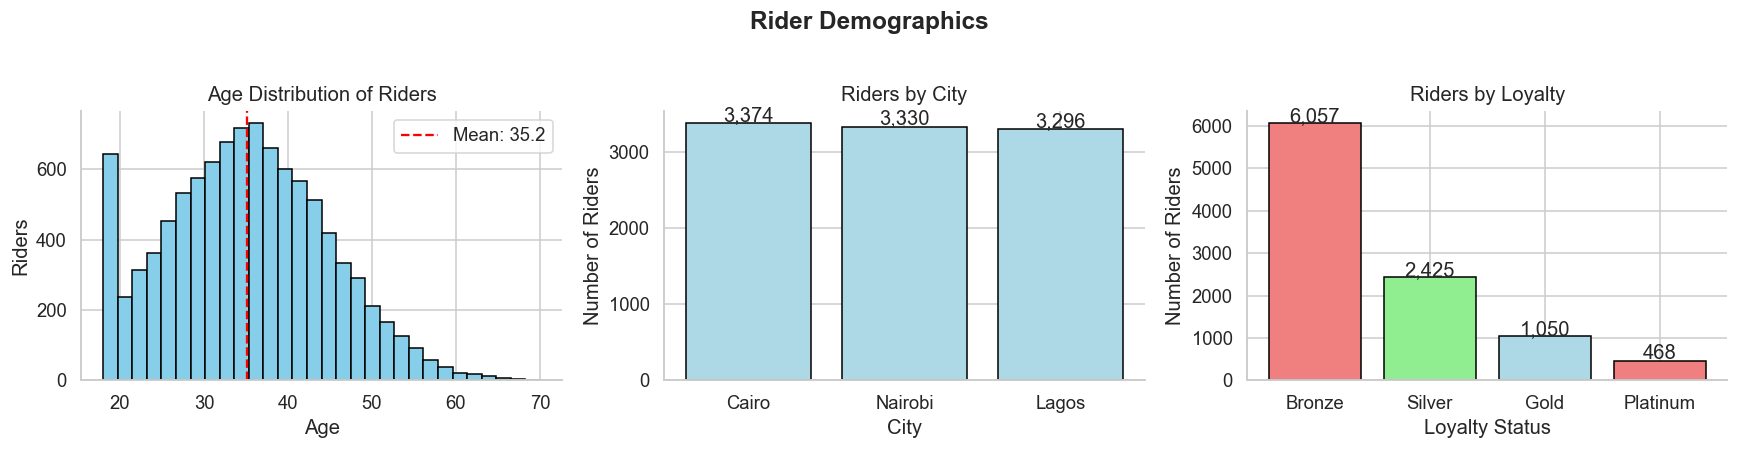

In [59]:
# Age distribution
# step 3a  define the figure size and style
fig, axes = plt.subplots(1,3, figsize=(16,4))

# step 3b plot the age distribution (18-30, 30-50, 50+)
axes[0].hist(riders["age"].dropna(), bins=30, color="skyblue", edgecolor="black")
axes[0].axvline(
    riders["age"].mean(), color="red", linestyle="dashed",
    label=f"Mean: {riders['age'].mean():.1f}"
    
    )

# step3c configure the plot
axes[0].set(title="Age Distribution of Riders", xlabel="Age", ylabel="Riders")
axes[0].legend()

##################################  PART 2 ######################################
# step 3d City Distribution
city_counts = riders["city"].value_counts()

# step 3e plot the city distibution
axes[1].bar(
    city_counts.index, city_counts.values,
    color="lightblue", edgecolor="black"
)

# step 3f configure the plot
for i, v in enumerate(city_counts.values):
    axes[1].text(i, v + 30, f"{v:,}", ha="center")
axes[1].set(title="Riders by City", xlabel="City", ylabel="Number of Riders")

##################################  PART 3 ######################################

# step 3g plot loyalty distribution
loyalty_counts = riders["loyalty_status"].value_counts()

axes[2].bar(
    loyalty_counts.index, loyalty_counts.values,
    color=["lightcoral", "lightgreen", "lightblue"], edgecolor="black"
)

# step 3h configure the plot
for i, v in enumerate(loyalty_counts.values):
    axes[2].text(i, v + 30, f"{v:,}" ,ha="center")
axes[2].set(title="Riders by Loyalty", xlabel="Loyalty Status", ylabel="Number of Riders")


plt.suptitle("Rider Demographics", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


#### STEP 4 - Churn Probability Column

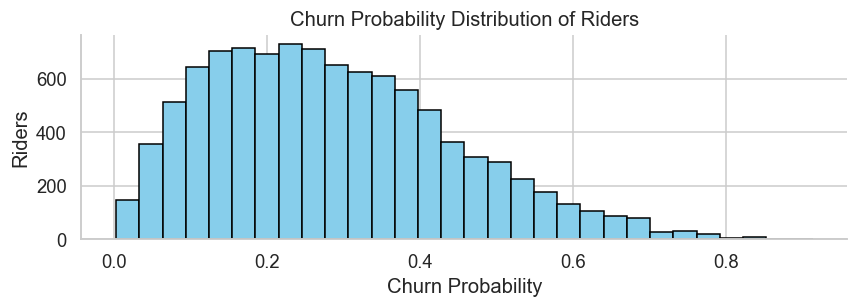

In [60]:
fig, ax = plt.subplots(figsize=(8,3))

ax.hist(
    riders["churn_prob"].dropna(), bins=30, color="skyblue", edgecolor="black")
ax.set(title="Churn Probability Distribution of Riders", xlabel="Churn Probability", ylabel="Riders")

plt.tight_layout()
plt.show()

#### STEP 5 - Sign Up trends overtime

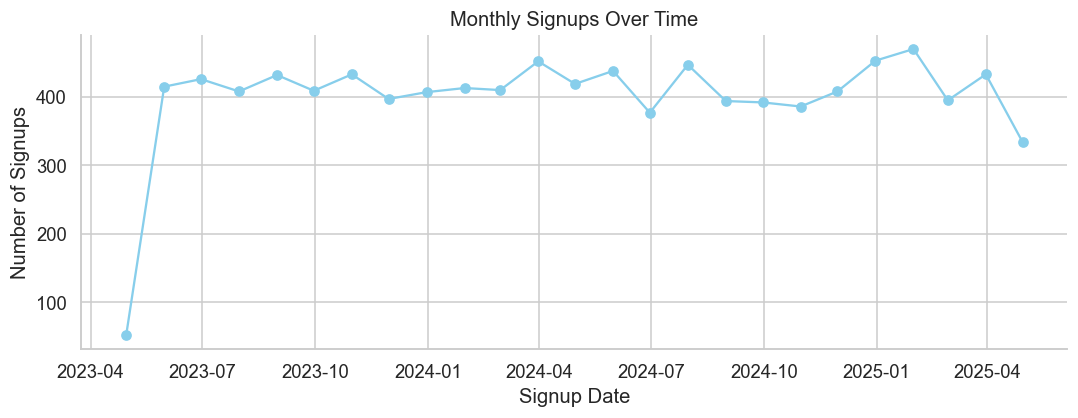

In [61]:
monthly = riders.set_index("signup_date").resample("ME").size().reset_index(name="signups")

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(monthly["signup_date"], monthly["signups"], marker="o", color="skyblue")
ax.set(title="Monthly Signups Over Time", xlabel="Signup Date", ylabel="Number of Signups")
plt.tight_layout()
plt.show()

#### Step 6 - Trips Analysis

In [62]:
trips.head()
print(f"Shape : {trips.shape}")
print(trips.dtypes)
print(trips.isnull().sum())

Shape : (200000, 16)
trip_id              object
user_id              object
driver_id            object
fare                float64
surge_multiplier    float64
tip                 float64
payment_type         object
pickup_time          object
dropoff_time         object
pickup_lat          float64
pickup_lng          float64
dropoff_lat         float64
dropoff_lng         float64
weather              object
city                 object
loyalty_status       object
dtype: object
trip_id             0
user_id             0
driver_id           0
fare                0
surge_multiplier    0
tip                 0
payment_type        0
pickup_time         0
dropoff_time        0
pickup_lat          0
pickup_lng          0
dropoff_lat         0
dropoff_lng         0
weather             0
city                0
loyalty_status      0
dtype: int64


In [63]:
trips.head()

,trip_id,user_id,driver_id,fare,surge_multiplier,tip,payment_type,pickup_time,dropoff_time,pickup_lat,pickup_lng,dropoff_lat,dropoff_lng,weather,city,loyalty_status
0,T000000,R05207,D00315,12.11,1.0,0.00,Card,2024-11-27 18:41:50+02:27,2024-11-27 19:33:50+02:27,-1.108123,36.912209,-1.068155,36.875377,Foggy,Nairobi,Bronze
1,T000001,R09453,D03717,8.73,1.0,0.02,Card,2024-10-28 23:13:48+00:14,2024-10-28 23:26:48+00:14,6.675266,3.515740,6.641734,3.525620,Sunny,Lagos,Gold
2,T000002,R00567,D02035,19.68,1.0,0.00,Card,2025-02-17 05:36:41+02:27,2025-02-17 05:52:41+02:27,-1.248589,37.010668,-1.273182,37.018586,Cloudy,Nairobi,Bronze
3,T000003,R09573,D02657,16.43,1.0,0.01,Mobile Money,2024-06-18 19:27:14+02:05,2024-06-18 19:32:14+02:05,29.819554,31.188780,29.837689,31.232978,Cloudy,Cairo,Bronze
4,T000004,R03446,D01026,8.70,1.0,1.06,Card,2024-10-05 09:58:16+02:27,2024-10-05 10:28:16+02:27,-1.676479,36.729219,-1.638395,36.694063,Sunny,Nairobi,Gold


#### Step 6a - Converted to proper Data format

In [64]:
# Fix timestamps
for col in ["pickup_time", "dropoff_time"]:
    trips[col] = pd.to_datetime( trips[col], utc=True, errors="coerce").dt.tz_localize(None)


##### Step 6b - Engineered Trip Features

###### 1 - Calculate the trip duration in minutes

- Pickup_time 
- Dropoff_time
- Dropoff_time - Pickup_time


###### 2 - Total revenue == eg $ 50 was suppose 30% surge multiplier and $ 5 tip amount


###### fare X surge_multiplier + tip_amount
- (segment high value customers)

###### 3 - hour of the day & day of the week = pickup_time and extract the hour 
- pickup_time and extract the day of the week



In [65]:
# step 1 --- duration of trips

trips["trip_duration_min"] = (
    ( trips["dropoff_time"] - trips["pickup_time"]).dt.total_seconds() / 60 
)

# step 1b --- total revenue
trips["total_revenue"] = trips["fare"] * trips["surge_multiplier"] + trips["tip"].fillna(0)

#step 1c --- hour of the day and day of the week
trips["hour_of_day"] = trips["pickup_time"].dt.hour
trips["day_of_week"] = trips["pickup_time"].dt.day_name()



#### Step 6c - Financial & Duration Distribution
- 1 - Fare distribution
- 2 - Surge
- 3 - Duration

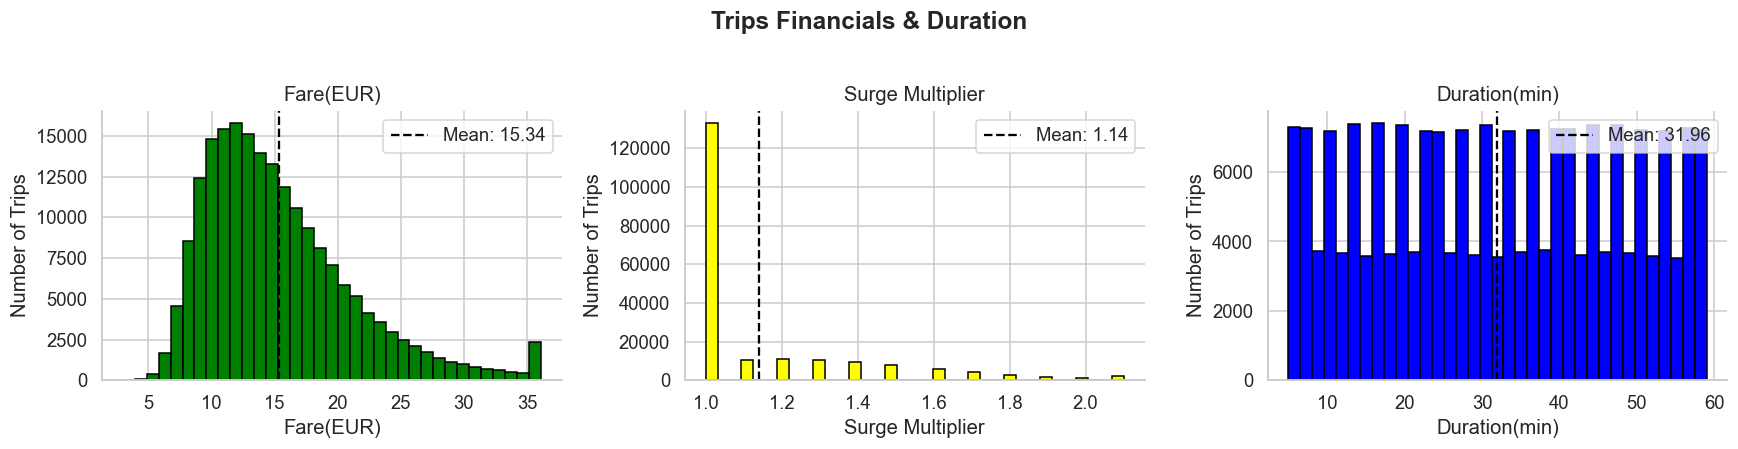

In [66]:
# step 6ci - distribution of trip durations, surge & fare
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, title, color in zip(
    axes,
    ["fare", "surge_multiplier", "trip_duration_min"],
    ["Fare(EUR)", "Surge Multiplier", "Duration(min)"],
    ["green", "yellow", "blue"],):

    #step 6cii - clip outliers at 99th percentile
    data = trips[col].clip(upper=trips[col].quantile(0.99)).dropna()

    # step 6ciii - plot the distribution
    ax.hist(data, bins=35, color=color, edgecolor="black")
    ax.axvline(
        data.mean(), color="black", linestyle="dashed",
        label=f"Mean: {data.mean():.2f}"
    )
    ax.set(title=title, xlabel=title, ylabel="Number of Trips")
    ax.legend()

plt.suptitle("Trips Financials & Duration", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

##### Step 6d - Temporal patterns : When Do people Ride

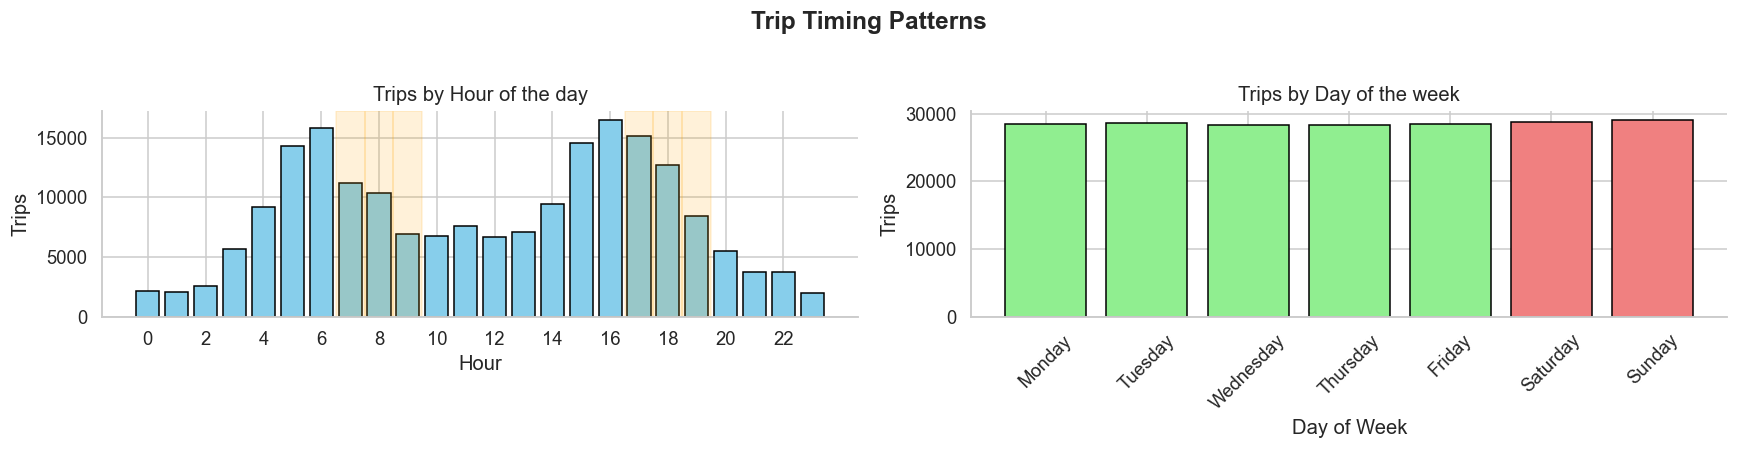

In [67]:
# Hour of the day & day of week
# Step 6di - distribution of trips by hour of the day and day of the week
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# step6dii - Hour of the day
hour_counts = trips["hour_of_day"].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values, color="skyblue", edgecolor="black")

# step 6dii - Vertical span to highlight rush hour
for h in [7,8,9,17,18,19]:
    axes[0].axvspan(h-0.5, h+0.5, alpha=0.15, color="orange")

# step 6diii - Set title and xticks
axes[0].set(title="Trips by Hour of the day", xlabel="Hour", ylabel="Trips")
axes[0].set_xticks(range(0, 24, 2))


# Step 7 - Day of week
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_counts = trips["day_of_week"].value_counts().reindex(day_order)
axes[1].bar(
    day_order,
    day_counts.values,
    color=["lightgreen"] * 5 + ["lightcoral"] * 2, edgecolor="black")
axes[1].set(title="Trips by Day of the week", xlabel="Day of Week", ylabel="Trips")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Trip Timing Patterns", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()




##### Step 6e - Payment & Weather Distribution


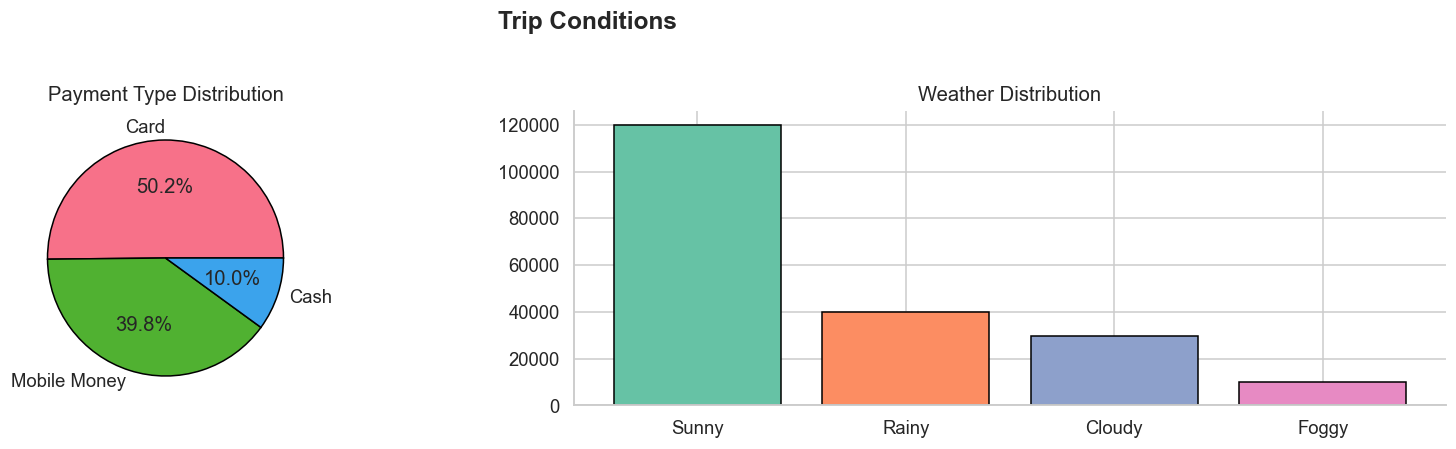

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# payment type distribution
payment_counts = trips["payment_type"].value_counts()
axes[0].pie(
    payment_counts.values, labels=payment_counts.index, autopct="%1.1f%%",
    colors=sns.color_palette("husl", len(payment_counts)),
    wedgeprops={"edgecolor":"black"}
)
axes[0].set(title="Payment Type Distribution")


# Weather Distribution
weather_counts = trips["weather"].value_counts()
axes[1].bar(
    weather_counts.index, weather_counts.values,
    color=sns.color_palette("Set2", len(weather_counts)), edgecolor="black"
)
axes[1].set(title="Weather Distribution")

plt.suptitle("Trip Conditions", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

#### Step 7 - Drivers Dataset Analysis

In [69]:
drivers.head()


,driver_id,rating,vehicle_type,signup_date,last_active,city,acceptance_rate
0,D00000,3.1,SUV,2025-01-20,2025-01-06 18:23:09.312275,Cairo,0.679555
1,D00001,5.0,Sedan,2023-03-27,2025-04-27 01:44:02.472554,Nairobi,0.548786
2,D00002,4.5,Motorcycle,2024-05-02,2025-03-07 19:24:46.367672,Nairobi,0.593724
3,D00003,5.0,Motorcycle,2023-04-16,2025-03-26 19:16:24.253793,Nairobi,0.990000
4,D00004,4.4,Motorcycle,2023-05-28,2025-04-08 18:54:44.649615,Lagos,0.519773


In [70]:
print(f"Shape : {drivers.shape}")
print(drivers.dtypes)
print(drivers.isnull().sum())

Shape : (5000, 7)
driver_id                  object
rating                    float64
vehicle_type               object
signup_date        datetime64[ns]
last_active                object
city                       object
acceptance_rate           float64
dtype: object
driver_id          0
rating             0
vehicle_type       0
signup_date        0
last_active        0
city               0
acceptance_rate    0
dtype: int64


#### Step 7a - Driver Fleet Composition

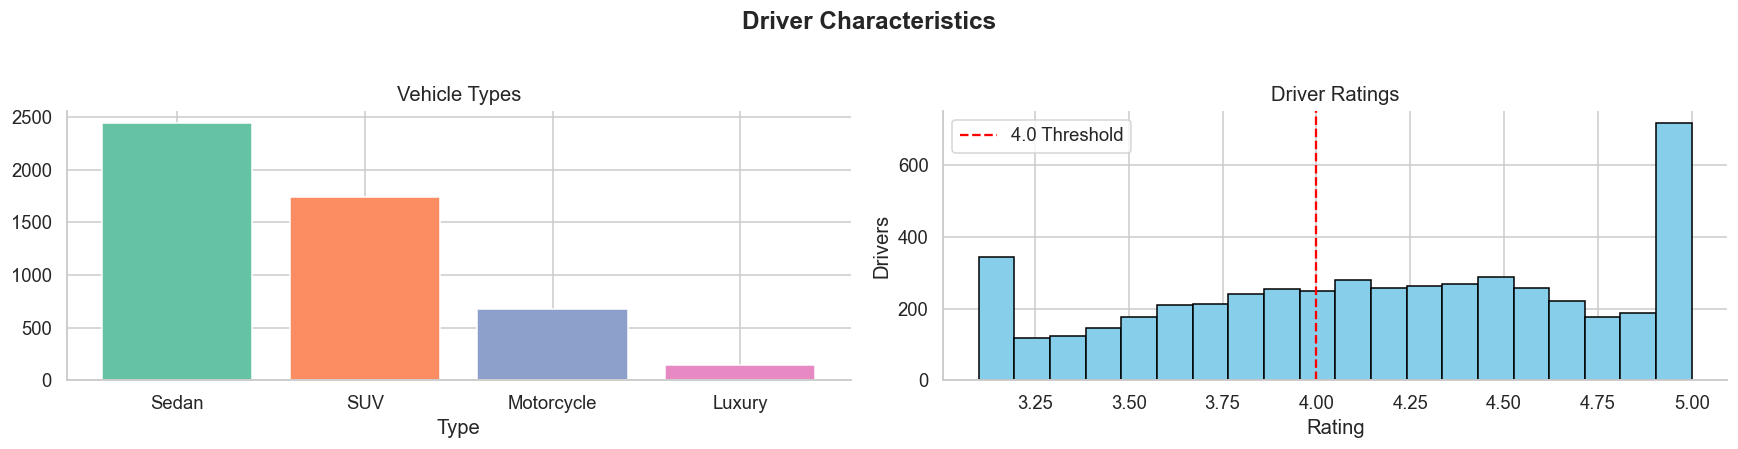

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(16,4))

#Vehicle type
vehicle_counts = drivers["vehicle_type"].value_counts()

axes[0].bar(
    vehicle_counts.index, vehicle_counts.values,
    color=sns.color_palette("Set2", len(vehicle_counts)), edgecolor="white"
)
axes[0].set(title="Vehicle Types", xlabel="Type", ylabel="")



# Rate Distribution
axes[1].hist(drivers["rating"].dropna(), bins=20, color="skyblue", edgecolor="black")
axes[1].axvline(4.0, color="red", linestyle="dashed", label="4.0 Threshold")
axes[1].set(title="Driver Ratings", xlabel="Rating", ylabel="Drivers")
axes[1].legend()


plt.suptitle("Driver Characteristics", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

#### Step 8 - Session Dataset Analysis

In [72]:
sessions.head()

,session_id,rider_id,session_time,time_on_app,pages_visited,converted,city,loyalty_status
0,S000000,R08605,2025-04-27 18:57:06+02:05,79,4,1,Cairo,Bronze
1,S000001,R08823,2025-04-27 07:32:22+02:27,101,3,0,Nairobi,Silver
2,S000002,R05342,2025-04-27 23:17:25+02:05,12,1,0,Cairo,Bronze
3,S000003,R05057,2025-04-27 14:40:25+00:14,19,1,0,Lagos,Silver
4,S000004,R09614,2025-04-27 08:31:22+00:14,4,1,0,Lagos,Bronze


In [73]:
print(f"Shape : {sessions.shape}")
print(sessions.dtypes)
print(sessions.isnull().sum())

Shape : (50000, 8)
session_id        object
rider_id          object
session_time      object
time_on_app        int64
pages_visited      int64
converted          int64
city              object
loyalty_status    object
dtype: object
session_id        0
rider_id          0
session_time      0
time_on_app       0
pages_visited     0
converted         0
city              0
loyalty_status    0
dtype: int64


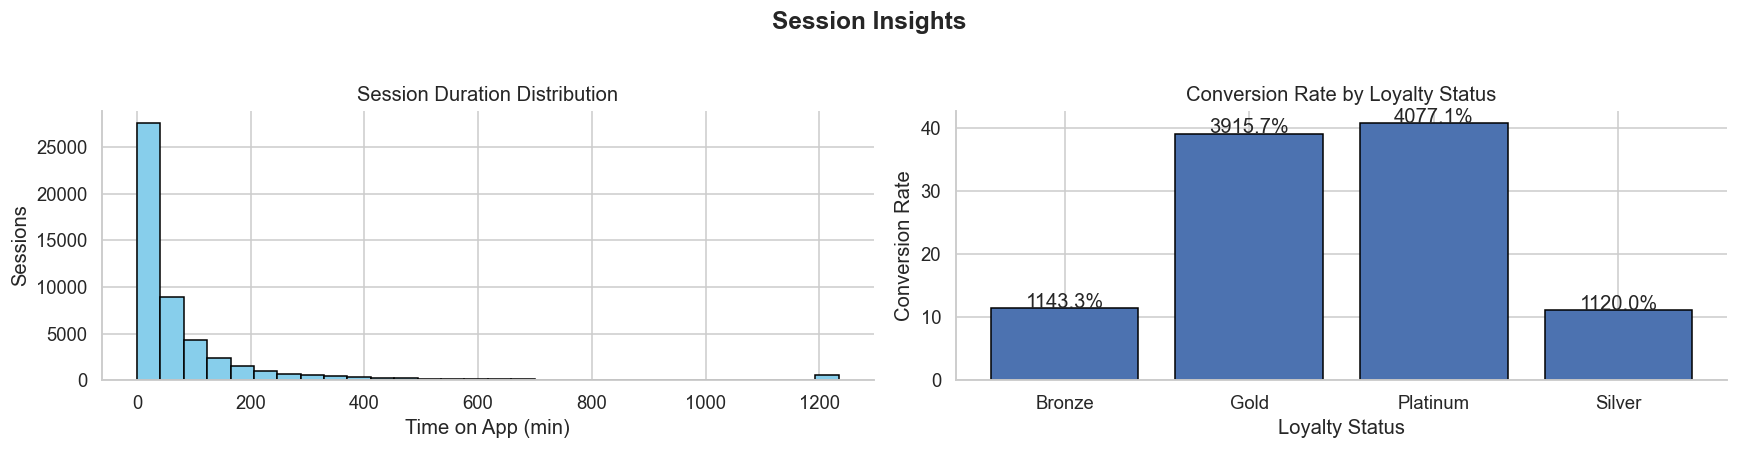

In [74]:
## Session table analysis

fig, axes = plt.subplots(1, 2, figsize=(16,4))

# Session duration distribution
axes[0].hist(
    sessions["time_on_app"].clip(upper=sessions["time_on_app"].quantile(0.99)).dropna(),
    bins=30, color="skyblue", edgecolor="black"

)
axes[0].set(title="Session Duration Distribution", xlabel="Time on App (min)", ylabel="Sessions")


# Conversion rate by loyalty status
conv_loyalty = sessions.groupby("loyalty_status")["converted"].mean().mul(100)
axes[1].bar(
    conv_loyalty.index, conv_loyalty.values, edgecolor="black")

for i, v in enumerate(conv_loyalty.values):
    axes[1].text(i, v + 0.01, f"{v:.1%}", ha="center")
axes[1].set(title="Conversion Rate by Loyalty Status", xlabel="Loyalty Status", ylabel="Conversion Rate")


plt.suptitle("Session Insights", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

#### Step 9 - Churn Analysis

In [75]:
riders["churn_prob"].head()

# Define a Threshold for churn
# churned = 1 if churn_prob > 0.5
# Not churned = 0 if churn_prob <= 0.5

0    0.142431
1    0.674161
2    0.510379
3    0.244779
4    0.269960
Name: churn_prob, dtype: float64

##### Step 9b - Churn Analysis

1 - converted our churn column to binary label
0.123, 0.345, 0.23 ---- Continuous probablilty AKA decimals
0,1,0,1,0,1  ------- binary label

2 - create a threshold = 0.5: standard decision boundary (>50% riders likely going to churn = churned)
capp who churned and who didnt churn to binary label (0,1)

3 - churned = 1 if the person's prob on the data is > 0.5
3b - Not churned = 0 if person's prob on the data is < 0.5

In [76]:
# Engineer a new column "churned" based on the threshold
riders["churned"] = (riders["churn_prob"] >= 0.5).astype(int)

# Calculate and print overall churn rate and total churned riders
print(f"Overall churn rate : {riders['churned'].mean() * 100:.1f}%")
print(f"churned : {riders['churned'].sum()}")

Overall churn rate : 10.6%
churned : 1063


#### Step 9c - Distribution of churn by Loyalty or City (Bi-variate analysis)

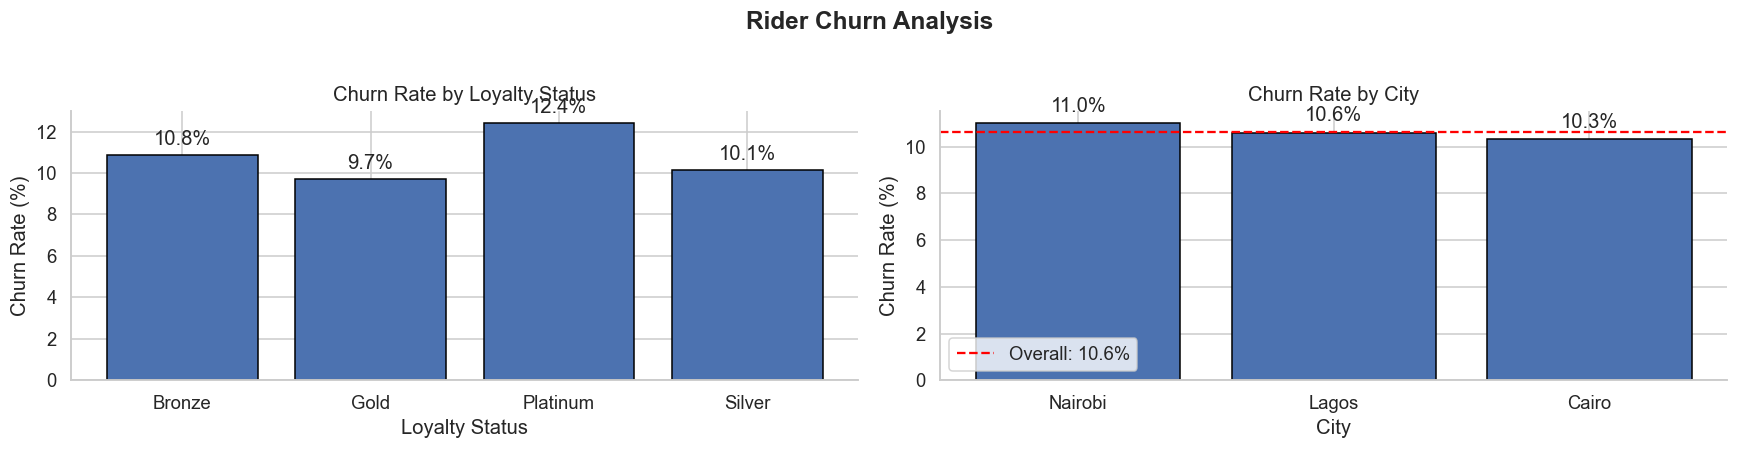

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(16,4))

# Churn by loyalty
churn_loyalty = riders.groupby("loyalty_status")["churned"].mean().mul(100)
axes[0].bar(churn_loyalty.index, churn_loyalty.values, edgecolor="black")

# Annotate the bars with the churn rates
for i, v in enumerate(churn_loyalty.values):
    axes[0].text(i, v + 0.5, f"{v:.1f}%", ha="center")
axes[0].set(title="Churn Rate by Loyalty Status", xlabel="Loyalty Status", ylabel="Churn Rate (%)")


# Churn by city
churn_city = riders.groupby("city")["churned"].mean().mul(100).sort_values(ascending=False)
overall = riders["churned"].mean() * 100

# Bar plot
axes[1].bar(churn_city.index, churn_city.values, edgecolor="black")
axes[1].axhline(overall, color="red", linestyle="dashed", label=f"Overall: {overall:.1f}%")

# Annotate the bars with the churn rates
for i, v in enumerate(churn_city.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center")
axes[1].set(title="Churn Rate by City", xlabel="City", ylabel="Churn Rate (%)")
axes[1].legend()


plt.suptitle("Rider Churn Analysis", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

##### Step 9d - Churn analysis final

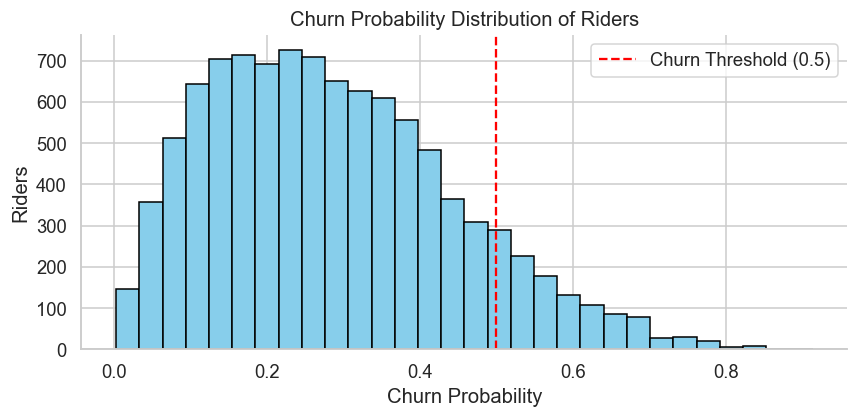

In [78]:
fig, ax = plt.subplots(figsize=(8,4))
ax.hist (
    riders["churn_prob"].dropna(), bins=30, color="skyblue", edgecolor="black"
)
ax.axvline(0.5, color="red", linestyle="dashed", label="Churn Threshold (0.5)")
ax.set(title="Churn Probability Distribution of Riders", xlabel="Churn Probability", ylabel="Riders")

ax.legend()
plt.tight_layout()
plt.show()